In [75]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

rng = np.random.default_rng()

In [130]:
df_freq = pl.read_csv("./data/insurance/freMTPL2freq.csv")

df_sev = pl.read_csv("./data/insurance/freMTPL2sev.csv", infer_schema_length=None).group_by("IDpol").sum()
# common_duplicate_values = df_sev["ClaimAmount"].value_counts().top_k(by="count", k=10)["ClaimAmount"].to_list()
# for value in common_duplicate_values:
#     replacement_rows = df_sev.filter(pl.col("ClaimAmount") == value)
#     jitters = rng.exponential(replacement_rows["ClaimAmount"])
#     replacement_rows = replacement_rows.with_columns(pl.col("ClaimAmount") + jitters)
#     df_sev = df_sev.with_columns(
#         ClaimAmount=pl.col("IDpol").replace_strict(
#             dict(zip(replacement_rows["IDpol"], replacement_rows["ClaimAmount"], strict=True)),
#             default=pl.col("ClaimAmount"),
#         )
#     )
# df_sev = df_sev.filter(~pl.col("ClaimAmount").is_in(common_duplicate_values))

df = df_freq.join(df_sev, on="IDpol", how="left", coalesce=True).with_columns(pl.col("ClaimAmount").fill_null(0))


In [131]:
df.filter(pl.col("ClaimAmount") > 0)["ClaimAmount"].describe()

statistic,value
str,f64
"""count""",24944.0
"""null_count""",0.0
"""mean""",2401.748577
"""std""",30264.753853
"""min""",1.0
"""25%""",749.83
"""50%""",1172.0
"""75%""",1346.4
"""max""",4.0754e6


(array([2.000e+00, 0.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 3.000e+00, 3.000e+00, 4.000e+00,
        1.100e+01, 5.000e+00, 6.000e+00, 1.200e+01, 1.300e+01, 1.500e+01,
        1.400e+01, 1.400e+01, 2.100e+01, 2.800e+01, 3.200e+01, 4.700e+01,
        4.000e+01, 4.500e+01, 9.100e+01, 2.520e+02, 7.250e+02, 2.620e+02,
        1.580e+02, 1.270e+02, 1.470e+02, 1.710e+02, 2.010e+02, 2.360e+02,
        2.360e+02, 2.840e+02, 3.310e+02, 3.470e+02, 4.080e+02, 7.390e+02,
        9.000e+02, 6.100e+02, 5.830e+02, 6.170e+02, 1.051e+04, 1.044e+03,
        7.620e+02, 7.070e+02, 7.020e+02, 7.080e+02, 4.810e+02, 4.270e+02,
        3.210e+02, 2.880e+02, 2.080e+02, 1.540e+02, 1.480e+02, 1.430e+02,
        1.240e+02, 8.100e+01, 5.700e+01, 5.800e+01, 3.800e+01, 3.400e+01,
        3.200e+01, 2.200e+01, 2.400e+01, 1.600e+01, 1.400e+01, 1.400e+01,
        1.100e+01, 1.600e+01, 5.000e+00, 4.000e+00, 8.000e+00, 4.000e+00,
        3.000e+00, 6.000e+00, 7.000e+0

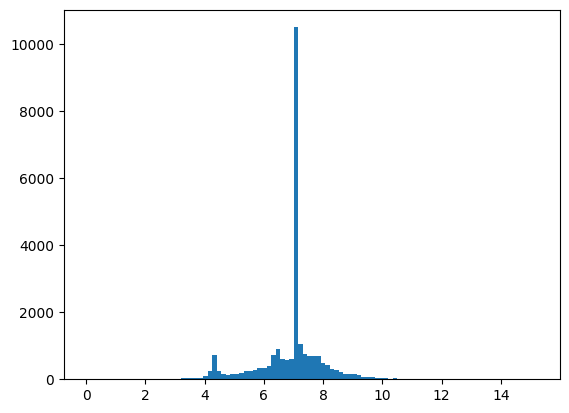

In [132]:
plt.hist(df.filter(pl.col("ClaimAmount") > 0)["ClaimAmount"].log(), bins=100)

In [133]:
us = np.linspace(0, 2500, 1000)

results = []
for u in us:
    results.append(df.filter(pl.col("ClaimAmount") > u).select((pl.col("ClaimAmount") - u).mean()).item())

Text(0, 0.5, 'Empirical Excess Mean')

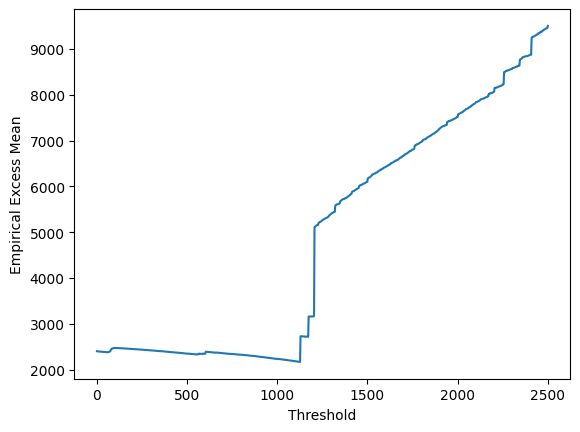

In [134]:
plt.plot(us, results)
plt.xlabel("Threshold")
plt.ylabel("Empirical Excess Mean")

(array([527., 397., 364., 263., 235., 269., 205., 226., 176., 166., 173.,
        220., 148., 236., 164., 117., 151., 103.,  78., 121.,  82.,  89.,
        142.,  49.,  65.,  39.,  57.,  60.,  73.,  45.,  36.,  59.,  35.,
         59.,  31.,  45.,  34.,  39.,  24.,  38.,  18.,  30.,  60.,  19.,
         32.,  21.,  20.,  28.,  25.,  21.,  22.,  14.,  17.,  16.,  23.,
         14.,  25.,  11.,   8.,  14.,  11.,  10.,   8.,  11.,  16.,  34.,
          6.,  23.,   4.,   2.,   8.,   6.,   8.,   6.,  23.,   6.,   6.,
         10.,  11.,  19.,  12.,  15.,   4.,   6.,  10.,   8.,  11.,   6.,
         11.,   9.,   5.,   6.,   6.,   3.,   6.,   8.,   6.,   8.,   7.,
         31.]),
 array([8.0000000e-02, 8.7579200e+01, 1.7507840e+02, 2.6257760e+02,
        3.5007680e+02, 4.3757600e+02, 5.2507520e+02, 6.1257440e+02,
        7.0007360e+02, 7.8757280e+02, 8.7507200e+02, 9.6257120e+02,
        1.0500704e+03, 1.1375696e+03, 1.2250688e+03, 1.3125680e+03,
        1.4000672e+03, 1.4875664e+03, 1.575065

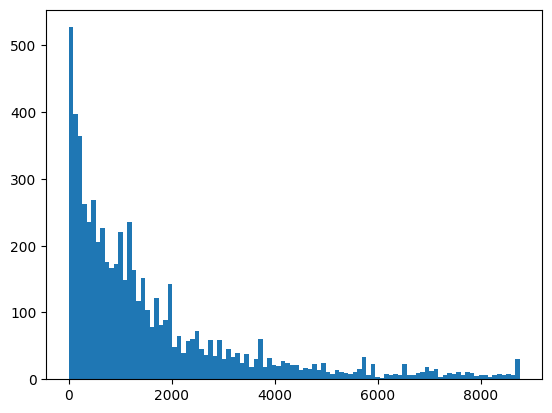

In [138]:
plt.hist(df.filter(pl.col("ClaimAmount") <= 10000, pl.col("ClaimAmount") > 1250)["ClaimAmount"] - 1250, bins=100)

In [139]:
results = []
for u in us:
    fit_data = df.filter(pl.col("ClaimAmount") > u)["ClaimAmount"]
    results.append(stats.genpareto.fit(fit_data))

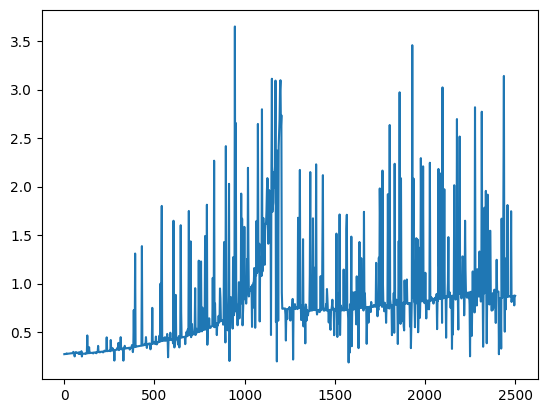

In [140]:
plt.plot(us, [x[0] for x in results])

In [188]:
test = df.filter(pl.col("ClaimAmount") > 0)["ClaimAmount"].sort(descending=True).to_numpy()

results = []
for k in range(1, len(test)):
    results.append((k, 1 / k * np.sum(np.log(test[:k] / test[k]))))

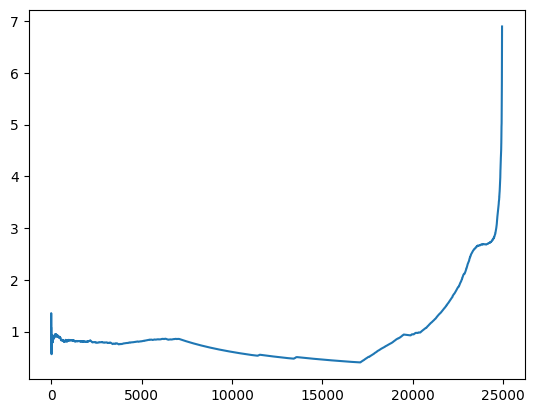

In [ ]:
plt.plot([x[0] for x in results], [x[1] for x in results])